# Project Title

Chicago Crime Data Analysis 2023 (BigQuery Public Dataset)

# Objective(Problem statment)

1. To identify the most frequently occurring crime types in Chicago during 2023 and analyze their distribution across different categories.
2. To examine arrest rates across various crime types and determine which categories have higher or lower rates of resolution.
3. To identify geographic crime hotspots by analyzing crime distribution across districts and wards using location data.
4. To uncover time-based crime patterns (by month, day of the week, and hour of day) to support data-driven insights for resource planning and public safety awareness.



# Outcome
Delivered a Power BI dashboard revealing key crime trends, hotspots, and arrest patterns in Chicago for 2023 to support data-driven public safety insights.

## Domain: Public Safety / Law Enforcement Analytics

# Dataset Information

**Source:** Google BigQuery Public Datasets (Open Data Portal) — bigquery-public-data.chicago_crime.crime

**Year / Timeline:** Data collected during 2023 (January 2023 to December 2023)

**Dataset Column/Features Description:**



*   unique_key – Unique identifier for each crime record
*   case_number – Chicago Police Department (CPD) case reference number
*   date – Date and time when the crime occurred
*   block – Approximate address/block where the crime took place
*  primary_type – Main category of the crime (e.g., Theft, Battery,     Assault, Robbery, Criminal Damage)
*  description – Detailed description of the specific crime type
*   location_description – Type of location where the crime occurred (e.g., street, residence, apartment)
*  arrest – Boolean indicating whether an arrest was made (True/False)
*   domestic – Boolean indicating whether the incident was classified as domestic-related (True/False)
*   beat – Police beat number where the crime occurred
*  district – Police district number
*   ward – City ward (political district) where the crime occurred
*   community_area – Community area code within Chicago
*   fbi_code – FBI classification code for the crime type
*   latitude – Latitude coordinate of the crime location
*   longitude – Longitude coordinate of the crime location
*  year – Year the crime was recorded (2023)






# Stages for DA Project

Stage 1 – Problem Definition and Dataset Selection

Business Problem and Expected Outcome

Law enforcement agencies and city administrators need clear visibility into crime patterns to allocate resources effectively, improve public safety planning, and respond proactively to high-risk areas and time periods. Without structured analysis, raw crime records remain difficult to interpret for decision-making. This project addresses that gap by analyzing 2023 Chicago crime data to uncover patterns in crime type, arrest rates, geographic hotspots, and time-based trends. The expected outcome is an interactive Power BI dashboard that presents these insights clearly, enabling data-driven decisions around patrol allocation, resource planning, and public safety awareness.

**Dataset Selection and Source**

The dataset used for this project is the Chicago Crime dataset, sourced from Google BigQuery Public Datasets (bigquery-public-data.chicago_crime.crime), an open data portal hosted on Google Cloud. The full dataset contains millions of crime records maintained by the Chicago Police Department; for this project, a filtered subset of 3,000 records from 2023 was extracted using SQL, focusing on five major crime types (Theft, Battery, Assault, Criminal Damage, and Robbery). The dataset includes 17 features, covering crime classification (primary type, description, FBI code), case details (case number, date), location information (block, district, ward, community area, latitude/longitude), and outcome indicators (arrest, domestic flag) — making it well-suited for time-based, categorical, and geographic analysis.

# Initial EDA

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

import warnings
warnings.filterwarnings('ignore')

In [ ]:
df=pd.read_csv('chicago_crime_2023.csv.csv')

In [ ]:
df.head()

,unique_key,case_number,date,block,primary_type,description,location_description,arrest,domestic,beat,district,ward,community_area,fbi_code,latitude,longitude,year
0,13172384,JG378607,2023-08-11 14:35:00.000000 UTC,001XX N MICHIGAN AVE,BATTERY,"AGGRAVATED - HANDS, FISTS, FEET, NO / MINOR IN...",SMALL RETAIL STORE,True,False,111,1,34,32,08B,41.883644,-87.624420,2023
1,13276137,JG502918,2023-11-13 13:15:00.000000 UTC,001XX N WABASH AVE,BATTERY,SIMPLE,SIDEWALK,False,False,111,1,34,32,08B,41.885433,-87.626265,2023
2,12984870,JG155021,2023-02-16 16:10:00.000000 UTC,001XX N WABASH AVE,BATTERY,SIMPLE,RESTAURANT,False,False,111,1,42,32,08B,41.885301,-87.626267,2023
3,13099278,JG291695,2023-06-07 11:32:00.000000 UTC,001XX N STATE ST,BATTERY,"AGGRAVATED P.O. - HANDS, FISTS, FEET, SERIOUS ...",CTA PLATFORM,True,False,111,1,42,32,04B,41.885482,-87.627936,2023
4,13053188,JG236699,2023-04-25 11:18:00.000000 UTC,0000X E LAKE ST,ASSAULT,SIMPLE,STREET,False,False,111,1,42,32,08A,41.885753,-87.626996,2023


In [ ]:
df.tail()

,unique_key,case_number,date,block,primary_type,description,location_description,arrest,domestic,beat,district,ward,community_area,fbi_code,latitude,longitude,year
2995,13181208,JG389101,2023-08-19 09:30:00.000000 UTC,015XX W BIRCHWOOD AVE,ASSAULT,AGGRAVATED - HANDGUN,STREET,False,False,2422,24,49,1,04A,42.018130,-87.670514,2023
2996,13028542,JG207390,2023-04-01 15:55:00.000000 UTC,017XX W HOWARD ST,ASSAULT,AGGRAVATED - KNIFE / CUTTING INSTRUMENT,GROCERY FOOD STORE,False,False,2422,24,49,1,04A,42.019399,-87.675049,2023
2997,12981600,JG149919,2023-02-06 11:00:00.000000 UTC,016XX W JONQUIL TER,ASSAULT,SIMPLE,APARTMENT,False,True,2422,24,49,1,08A,42.021162,-87.671421,2023
2998,13002049,JG175743,2023-03-05 18:00:00.000000 UTC,077XX N SHERIDAN RD,THEFT,$500 AND UNDER,STREET,False,False,2422,24,49,1,06,42.021626,-87.666720,2023
2999,13080465,JG269624,2023-05-21 21:08:00.000000 UTC,017XX W HOWARD ST,THEFT,$500 AND UNDER,GROCERY FOOD STORE,False,False,2422,24,49,1,06,42.019399,-87.675049,2023


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3000 entries, 0 to 2999
Data columns (total 17 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   unique_key            3000 non-null   int64  
 1   case_number           3000 non-null   object 
 2   date                  3000 non-null   object 
 3   block                 3000 non-null   object 
 4   primary_type          3000 non-null   object 
 5   description           3000 non-null   object 
 6   location_description  3000 non-null   object 
 7   arrest                3000 non-null   bool   
 8   domestic              3000 non-null   bool   
 9   beat                  3000 non-null   int64  
 10  district              3000 non-null   int64  
 11  ward                  3000 non-null   int64  
 12  community_area        3000 non-null   int64  
 13  fbi_code              3000 non-null   object 
 14  latitude              3000 non-null   float64
 15  longitude            

In [ ]:
df.shape

(3000, 17)

In [ ]:
df.columns.tolist()

['unique_key',
 'case_number',
 'date',
 'block',
 'primary_type',
 'description',
 'location_description',
 'arrest',
 'domestic',
 'beat',
 'district',
 'ward',
 'community_area',
 'fbi_code',
 'latitude',
 'longitude',
 'year']

In [ ]:
df.describe()

,unique_key,beat,district,ward,community_area,latitude,longitude,year
count,3.000000e+03,3000.000000,3000.000000,3000.000000,3000.000000,3000.000000,3000.000000,3000.0
mean,1.313563e+07,1054.945667,10.320667,22.515000,36.851333,41.841329,-87.663602,2023.0
std,1.114881e+05,620.073228,6.197202,13.887743,21.367282,0.086074,0.058828,0.0
min,1.293848e+07,111.000000,1.000000,1.000000,1.000000,41.651431,-87.906463,2023.0
25%,1.303997e+07,523.000000,5.000000,9.000000,23.000000,41.767439,-87.702516,2023.0
50%,1.313525e+07,1011.000000,10.000000,21.000000,32.000000,41.854265,-87.657017,2023.0
75%,1.322933e+07,1621.000000,16.000000,33.000000,53.000000,41.901268,-87.624677,2023.0
max,1.353382e+07,2422.000000,24.000000,50.000000,77.000000,42.021626,-87.525820,2023.0


In [ ]:
df.isnull().sum()

,0
unique_key,0
case_number,0
date,0
block,0
primary_type,0
description,0
location_description,0
arrest,0
domestic,0
beat,0


In [ ]:
df.duplicated().sum()

np.int64(0)

In [ ]:
df[df.duplicated()]

,unique_key,case_number,date,block,primary_type,description,location_description,arrest,domestic,beat,district,ward,community_area,fbi_code,latitude,longitude,year


**Stage 2 –** **Data Cleaning and Pre-processing**

Handle missing values (impute or drop)

Handle duplicates

column name rename or dropping unwanted columns if required

Treat outliers if required

Check skewness and apply transformations

Convert data types if needed

Feature transformations (date parts, derived fields if required for analysis)

In [ ]:
df.columns.tolist()

['unique_key',
 'case_number',
 'date',
 'block',
 'primary_type',
 'description',
 'location_description',
 'arrest',
 'domestic',
 'beat',
 'district',
 'ward',
 'community_area',
 'fbi_code',
 'latitude',
 'longitude',
 'year']

In [ ]:
df.dtypes

,0
unique_key,int64
case_number,object
date,object
block,object
primary_type,object
description,object
location_description,object
arrest,bool
domestic,bool
beat,int64


In [ ]:
#converting to timzzone
df['date'] = pd.to_datetime(df['date'])

In [ ]:
#converting data types
df['date'].dtype

datetime64[ns, UTC]

In [ ]:
df.head()

,unique_key,case_number,date,block,primary_type,description,location_description,arrest,domestic,beat,district,ward,community_area,fbi_code,latitude,longitude,year
0,13172384,JG378607,2023-08-11 14:35:00+00:00,001XX N MICHIGAN AVE,BATTERY,"AGGRAVATED - HANDS, FISTS, FEET, NO / MINOR IN...",SMALL RETAIL STORE,True,False,111,1,34,32,08B,41.883644,-87.624420,2023
1,13276137,JG502918,2023-11-13 13:15:00+00:00,001XX N WABASH AVE,BATTERY,SIMPLE,SIDEWALK,False,False,111,1,34,32,08B,41.885433,-87.626265,2023
2,12984870,JG155021,2023-02-16 16:10:00+00:00,001XX N WABASH AVE,BATTERY,SIMPLE,RESTAURANT,False,False,111,1,42,32,08B,41.885301,-87.626267,2023
3,13099278,JG291695,2023-06-07 11:32:00+00:00,001XX N STATE ST,BATTERY,"AGGRAVATED P.O. - HANDS, FISTS, FEET, SERIOUS ...",CTA PLATFORM,True,False,111,1,42,32,04B,41.885482,-87.627936,2023
4,13053188,JG236699,2023-04-25 11:18:00+00:00,0000X E LAKE ST,ASSAULT,SIMPLE,STREET,False,False,111,1,42,32,08A,41.885753,-87.626996,2023


In [ ]:
#creating new columns
df['date_only'] = df['date'].dt.date
df['time_only'] = df['date'].dt.time

In [ ]:
df.head()

,unique_key,case_number,date,block,primary_type,description,location_description,arrest,domestic,beat,district,ward,community_area,fbi_code,latitude,longitude,year,date_only,time_only
0,13172384,JG378607,2023-08-11 14:35:00+00:00,001XX N MICHIGAN AVE,BATTERY,"AGGRAVATED - HANDS, FISTS, FEET, NO / MINOR IN...",SMALL RETAIL STORE,True,False,111,1,34,32,08B,41.883644,-87.624420,2023,2023-08-11,14:35:00
1,13276137,JG502918,2023-11-13 13:15:00+00:00,001XX N WABASH AVE,BATTERY,SIMPLE,SIDEWALK,False,False,111,1,34,32,08B,41.885433,-87.626265,2023,2023-11-13,13:15:00
2,12984870,JG155021,2023-02-16 16:10:00+00:00,001XX N WABASH AVE,BATTERY,SIMPLE,RESTAURANT,False,False,111,1,42,32,08B,41.885301,-87.626267,2023,2023-02-16,16:10:00
3,13099278,JG291695,2023-06-07 11:32:00+00:00,001XX N STATE ST,BATTERY,"AGGRAVATED P.O. - HANDS, FISTS, FEET, SERIOUS ...",CTA PLATFORM,True,False,111,1,42,32,04B,41.885482,-87.627936,2023,2023-06-07,11:32:00
4,13053188,JG236699,2023-04-25 11:18:00+00:00,0000X E LAKE ST,ASSAULT,SIMPLE,STREET,False,False,111,1,42,32,08A,41.885753,-87.626996,2023,2023-04-25,11:18:00


In [ ]:
df['hour'] = df['date'].dt.hour

In [ ]:
df.columns.tolist()

['unique_key',
 'case_number',
 'date',
 'block',
 'primary_type',
 'description',
 'location_description',
 'arrest',
 'domestic',
 'beat',
 'district',
 'ward',
 'community_area',
 'fbi_code',
 'latitude',
 'longitude',
 'year',
 'date_only',
 'time_only',
 'hour']

In [ ]:
df['day_of_week'] = df['date'].dt.day_name()
df['month'] = df['date'].dt.month_name()

In [ ]:
df[['date_only', 'time_only', 'hour']].head()

,date_only,time_only,hour
0,2023-08-11,14:35:00,14
1,2023-11-13,13:15:00,13
2,2023-02-16,16:10:00,16
3,2023-06-07,11:32:00,11
4,2023-04-25,11:18:00,11


In [ ]:
df[['date_only', 'time_only', 'hour', 'day_of_week', 'month']]

,date_only,time_only,hour,day_of_week,month
0,2023-08-11,14:35:00,14,Friday,August
1,2023-11-13,13:15:00,13,Monday,November
2,2023-02-16,16:10:00,16,Thursday,February
3,2023-06-07,11:32:00,11,Wednesday,June
4,2023-04-25,11:18:00,11,Tuesday,April
...,...,...,...,...,...
2995,2023-08-19,09:30:00,9,Saturday,August
2996,2023-04-01,15:55:00,15,Saturday,April
2997,2023-02-06,11:00:00,11,Monday,February
2998,2023-03-05,18:00:00,18,Sunday,March


In [ ]:
df.head(10)

,unique_key,case_number,date,block,primary_type,description,location_description,arrest,domestic,beat,...,community_area,fbi_code,latitude,longitude,year,date_only,time_only,hour,day_of_week,month
0,13172384,JG378607,2023-08-11 14:35:00+00:00,001XX N MICHIGAN AVE,BATTERY,"AGGRAVATED - HANDS, FISTS, FEET, NO / MINOR IN...",SMALL RETAIL STORE,True,False,111,...,32,08B,41.883644,-87.624420,2023,2023-08-11,14:35:00,14,Friday,August
1,13276137,JG502918,2023-11-13 13:15:00+00:00,001XX N WABASH AVE,BATTERY,SIMPLE,SIDEWALK,False,False,111,...,32,08B,41.885433,-87.626265,2023,2023-11-13,13:15:00,13,Monday,November
2,12984870,JG155021,2023-02-16 16:10:00+00:00,001XX N WABASH AVE,BATTERY,SIMPLE,RESTAURANT,False,False,111,...,32,08B,41.885301,-87.626267,2023,2023-02-16,16:10:00,16,Thursday,February
3,13099278,JG291695,2023-06-07 11:32:00+00:00,001XX N STATE ST,BATTERY,"AGGRAVATED P.O. - HANDS, FISTS, FEET, SERIOUS ...",CTA PLATFORM,True,False,111,...,32,04B,41.885482,-87.627936,2023,2023-06-07,11:32:00,11,Wednesday,June
4,13053188,JG236699,2023-04-25 11:18:00+00:00,0000X E LAKE ST,ASSAULT,SIMPLE,STREET,False,False,111,...,32,08A,41.885753,-87.626996,2023,2023-04-25,11:18:00,11,Tuesday,April
5,13183628,JG392185,2023-08-21 17:50:00+00:00,001XX N WABASH AVE,ASSAULT,SIMPLE,RESTAURANT,False,False,111,...,32,08A,41.885301,-87.626267,2023,2023-08-21,17:50:00,17,Monday,August
6,13263055,JG487308,2023-09-18 12:00:00+00:00,001XX N STATE ST,THEFT,OVER $500,OTHER (SPECIFY),False,False,111,...,32,06,41.884650,-87.627915,2023,2023-09-18,12:00:00,12,Monday,September
7,13317280,JG552533,2023-12-23 18:14:00+00:00,001XX N STATE ST,THEFT,RETAIL THEFT,DEPARTMENT STORE,True,False,111,...,32,06,41.883500,-87.627877,2023,2023-12-23,18:14:00,18,Saturday,December
8,13010448,JG185654,2023-03-14 17:06:00+00:00,001XX N STATE ST,THEFT,RETAIL THEFT,DEPARTMENT STORE,True,False,111,...,32,06,41.883500,-87.627877,2023,2023-03-14,17:06:00,17,Tuesday,March
9,13012317,JG188246,2023-03-16 18:42:00+00:00,001XX N STATE ST,THEFT,RETAIL THEFT,COMMERCIAL / BUSINESS OFFICE,False,False,111,...,32,06,41.883500,-87.627877,2023,2023-03-16,18:42:00,18,Thursday,March


In [ ]:
#drop the existing column
#df = df.drop(columns=['date'])

In [ ]:
df.columns.tolist()

['unique_key',
 'case_number',
 'date',
 'block',
 'primary_type',
 'description',
 'location_description',
 'arrest',
 'domestic',
 'beat',
 'district',
 'ward',
 'community_area',
 'fbi_code',
 'latitude',
 'longitude',
 'year',
 'date_only',
 'time_only',
 'hour',
 'day_of_week',
 'month']

In [ ]:
df = df.rename(columns={'date_only': 'dates', 'time_only': 'time'})

In [ ]:
df.columns

Index(['unique_key', 'case_number', 'date', 'block', 'primary_type',
       'description', 'location_description', 'arrest', 'domestic', 'beat',
       'district', 'ward', 'community_area', 'fbi_code', 'latitude',
       'longitude', 'year', 'dates', 'time', 'hour', 'day_of_week', 'month'],
      dtype='object')

In [ ]:
df.to_csv('chicago_crimes_cleaned.csv', index=False)

In [ ]:
df['primary_type'].value_counts()

,count
primary_type,
THEFT,1062
BATTERY,801
CRIMINAL DAMAGE,559
ASSAULT,387
ROBBERY,191


In [ ]:
df['description'].value_counts()

,count
description,
SIMPLE,517
OVER $500,378
DOMESTIC BATTERY SIMPLE,360
$500 AND UNDER,357
TO VEHICLE,333
TO PROPERTY,208
RETAIL THEFT,187
AGGRAVATED - HANDGUN,122
FROM BUILDING,98


In [ ]:
df['description'].unique()

array(['AGGRAVATED - HANDS, FISTS, FEET, NO / MINOR INJURY', 'SIMPLE',
       'AGGRAVATED P.O. - HANDS, FISTS, FEET, SERIOUS INJURY',
       'OVER $500', 'RETAIL THEFT', 'POCKET-PICKING', 'FROM BUILDING',
       'TO PROPERTY', 'ARMED - HANDGUN', '$500 AND UNDER',
       'AGGRAVATED - KNIFE / CUTTING INSTRUMENT', 'TO VEHICLE',
       'ARMED - KNIFE / CUTTING INSTRUMENT',
       'AGGRAVATED P.O. - HANDS, FISTS, FEET, NO / MINOR INJURY',
       'ARMED - OTHER DANGEROUS WEAPON', 'STRONG ARM - NO WEAPON',
       'DOMESTIC BATTERY SIMPLE', 'ARMED - OTHER FIREARM',
       'VEHICULAR HIJACKING', 'AGGRAVATED - OTHER DANGEROUS WEAPON',
       'TO CITY OF CHICAGO PROPERTY', 'ATTEMPT STRONG ARM - NO WEAPON',
       'AGGRAVATED OF A SENIOR CITIZEN', 'CRIMINAL DEFACEMENT',
       'ATTEMPT ARMED - HANDGUN',
       'AGGRAVATED POLICE OFFICER - OTHER DANGEROUS WEAPON',
       'AGGRAVATED - HANDGUN', 'AGGRAVATED - OTHER FIREARM',
       'AGGRAVATED DOMESTIC BATTERY - OTHER DANGEROUS WEAPON',
       'TO 

In [ ]:
df['simple_description'] = np.where(
    df['description'].str.contains('AGGRAVATED'),
    'AGGRAVATED',
    df['description']
)

In [ ]:
df= df.rename(columns={'simple_description': 'Crime_Description'})

In [ ]:
df.columns

Index(['unique_key', 'case_number', 'date', 'block', 'primary_type',
       'description', 'location_description', 'arrest', 'domestic', 'beat',
       'district', 'ward', 'community_area', 'fbi_code', 'latitude',
       'longitude', 'year', 'dates', 'time', 'hour', 'day_of_week', 'month',
       'Crime_Description'],
      dtype='object')

In [ ]:
df[['description', 'Crime_Description']].head(20)

,description,Crime_Description
0,"AGGRAVATED - HANDS, FISTS, FEET, NO / MINOR IN...",AGGRAVATED
1,SIMPLE,SIMPLE
2,SIMPLE,SIMPLE
3,"AGGRAVATED P.O. - HANDS, FISTS, FEET, SERIOUS ...",AGGRAVATED
4,SIMPLE,SIMPLE
5,SIMPLE,SIMPLE
6,OVER $500,OVER $500
7,RETAIL THEFT,RETAIL THEFT
8,RETAIL THEFT,RETAIL THEFT
9,RETAIL THEFT,RETAIL THEFT


In [ ]:
df.head(20)

,unique_key,case_number,date,block,primary_type,description,location_description,arrest,domestic,beat,...,fbi_code,latitude,longitude,year,dates,time,hour,day_of_week,month,Crime_Description
0,13172384,JG378607,2023-08-11 14:35:00+00:00,001XX N MICHIGAN AVE,BATTERY,"AGGRAVATED - HANDS, FISTS, FEET, NO / MINOR IN...",SMALL RETAIL STORE,True,False,111,...,08B,41.883644,-87.624420,2023,2023-08-11,14:35:00,14,Friday,August,AGGRAVATED
1,13276137,JG502918,2023-11-13 13:15:00+00:00,001XX N WABASH AVE,BATTERY,SIMPLE,SIDEWALK,False,False,111,...,08B,41.885433,-87.626265,2023,2023-11-13,13:15:00,13,Monday,November,SIMPLE
2,12984870,JG155021,2023-02-16 16:10:00+00:00,001XX N WABASH AVE,BATTERY,SIMPLE,RESTAURANT,False,False,111,...,08B,41.885301,-87.626267,2023,2023-02-16,16:10:00,16,Thursday,February,SIMPLE
3,13099278,JG291695,2023-06-07 11:32:00+00:00,001XX N STATE ST,BATTERY,"AGGRAVATED P.O. - HANDS, FISTS, FEET, SERIOUS ...",CTA PLATFORM,True,False,111,...,04B,41.885482,-87.627936,2023,2023-06-07,11:32:00,11,Wednesday,June,AGGRAVATED
4,13053188,JG236699,2023-04-25 11:18:00+00:00,0000X E LAKE ST,ASSAULT,SIMPLE,STREET,False,False,111,...,08A,41.885753,-87.626996,2023,2023-04-25,11:18:00,11,Tuesday,April,SIMPLE
5,13183628,JG392185,2023-08-21 17:50:00+00:00,001XX N WABASH AVE,ASSAULT,SIMPLE,RESTAURANT,False,False,111,...,08A,41.885301,-87.626267,2023,2023-08-21,17:50:00,17,Monday,August,SIMPLE
6,13263055,JG487308,2023-09-18 12:00:00+00:00,001XX N STATE ST,THEFT,OVER $500,OTHER (SPECIFY),False,False,111,...,06,41.884650,-87.627915,2023,2023-09-18,12:00:00,12,Monday,September,OVER $500
7,13317280,JG552533,2023-12-23 18:14:00+00:00,001XX N STATE ST,THEFT,RETAIL THEFT,DEPARTMENT STORE,True,False,111,...,06,41.883500,-87.627877,2023,2023-12-23,18:14:00,18,Saturday,December,RETAIL THEFT
8,13010448,JG185654,2023-03-14 17:06:00+00:00,001XX N STATE ST,THEFT,RETAIL THEFT,DEPARTMENT STORE,True,False,111,...,06,41.883500,-87.627877,2023,2023-03-14,17:06:00,17,Tuesday,March,RETAIL THEFT
9,13012317,JG188246,2023-03-16 18:42:00+00:00,001XX N STATE ST,THEFT,RETAIL THEFT,COMMERCIAL / BUSINESS OFFICE,False,False,111,...,06,41.883500,-87.627877,2023,2023-03-16,18:42:00,18,Thursday,March,RETAIL THEFT


In [ ]:
df.to_csv('data_chicago_crimes_cleaned.csv', index=False)

In [ ]:
df['arrest'].value_counts()

,count
arrest,
False,2769
True,231


In [ ]:
df['domestic'].value_counts()

,count
domestic,
False,2328
True,672


In [ ]:
df['ward'].value_counts()

,count
ward,
27,158
28,137
6,116
42,114
20,111
8,109
17,105
16,102
7,101


In [ ]:
df[df.duplicated()]

,unique_key,case_number,date,block,primary_type,description,location_description,arrest,domestic,beat,...,fbi_code,latitude,longitude,year,dates,time,hour,day_of_week,month,Crime_Description


In [ ]:
df[['latitude', 'longitude']].describe()

,latitude,longitude
count,3000.000000,3000.000000
mean,41.841329,-87.663602
std,0.086074,0.058828
min,41.651431,-87.906463
25%,41.767439,-87.702516
50%,41.854265,-87.657017
75%,41.901268,-87.624677
max,42.021626,-87.525820


In [ ]:
#drop the columns
df = df.drop(columns=['fbi_code'])

In [ ]:
df.columns.tolist()

['unique_key',
 'case_number',
 'date',
 'block',
 'primary_type',
 'description',
 'location_description',
 'arrest',
 'domestic',
 'beat',
 'district',
 'ward',
 'community_area',
 'latitude',
 'longitude',
 'year',
 'dates',
 'time',
 'hour',
 'day_of_week',
 'month',
 'Crime_Description']

In [ ]:
(df == '').sum()          # empty strings
(df == 'UNKNOWN').sum()   # placeholder values, if any

,0
unique_key,0
case_number,0
date,0
block,0
primary_type,0
description,0
location_description,0
arrest,0
domestic,0
beat,0


*Stage 3*

** EDA and Visualizations**

Univariate Analysis → distribution of single variables (countplot, histogram, boxplot)

Bivariate Analysis → relation between two variables (scatterplot, barplot, correlation heatmap)

Multivariate Analysis → relation among 3+ variables (pairplot, grouped analysis, pivot tables, advanced plots)

**Type of Analysis**

Descriptive Analysis (summarizing the dataset)

Diagnostic Analysis (finding reasons behind patterns)

Predictive Analysis  

Prescriptive Analysis  (Resource Optimization)

**Analysis about the crime ratings** Univariate

In [ ]:
#count of district_wise crime
district_wise_crime = df.groupby('district').size()

In [ ]:
print(district_wise_crime)

district
1     166
2     147
3     164
4     196
5     129
6     199
7     156
8     202
9     139
10    130
11    147
12    221
14    117
15    106
16    126
17    114
18    149
19    189
20     80
22     74
24     49
dtype: int64


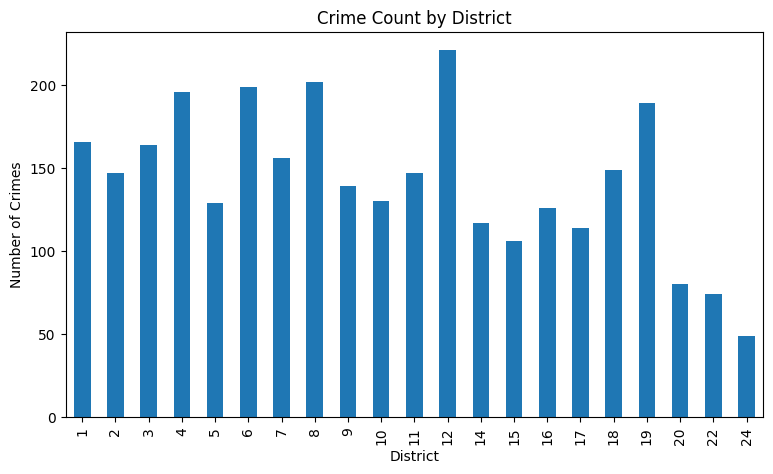

In [ ]:
# Visulas

district_wise_crime.plot(kind='bar', figsize=(9,5))
plt.title('Crime Count by District')
plt.xlabel('District')
plt.ylabel('Number of Crimes')
plt.show()

What features/columns did you use?

I used the district column.
I used the groupby() function to group the crime records according to each district.
I used size() to count the number of records/crimes in each district.

What does the chart say?

The chart shows the number of reported crimes in each district.
Each district is represented as a category.
The height of each bar represents the crime count for that district.

**  Interpretation **
   
   This chart helps us compare crime occurrences across different districts.
It shows which districts have higher or lower numbers of reported crime records.
From this analysis, we can identify districts that may require further investigation based on their reported crime volume.

In [ ]:
#count of crime types
crime_type_count = df.groupby('primary_type').size()


In [ ]:
print(crime_type_count )

primary_type
ASSAULT             387
BATTERY             801
CRIMINAL DAMAGE     559
ROBBERY             191
THEFT              1062
dtype: int64


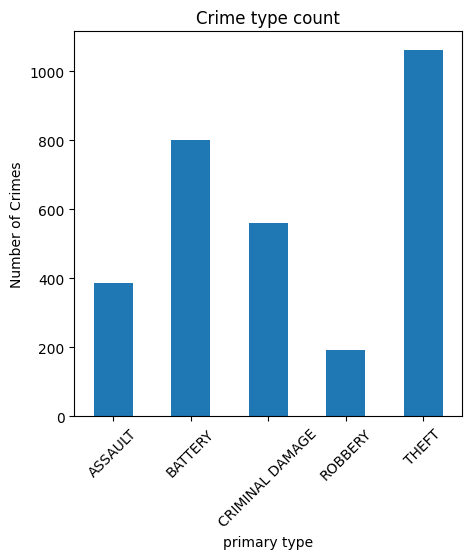

In [ ]:
crime_type_count.plot(kind='bar', figsize=(5,5))
plt.title('Crime type count')
plt.xlabel('primary type')
plt.ylabel('Number of Crimes')
plt.xticks(rotation=45)
plt.show()

What features/columns did you use?
I used the primary_type column.
primary_type represents the main category/type of reported crime.
groupby('primary_type') groups all records according to their crime type.
.size() counts how many records belong to each crime type.

The chart shows the number of reported crime records for each crime type.
Each bar represents a different crime type.
The height of the bar represents the number of reported records for that crime type.

**Interpretation**


This chart helps us understand which types of crimes are reported more frequently and which are reported less frequently in the dataset.
We can compare the frequency of different crime categories.

In [ ]:
df['district'].value_counts()

,count
district,
12,221
8,202
6,199
4,196
19,189
1,166
3,164
7,156
18,149


In [ ]:
#Ward_wise_crime
Ward_wise_crime = df.groupby('ward').size()

In [ ]:
print(Ward_wise_crime)

ward
1      57
2      37
3      86
4      93
5      70
6     116
7     101
8     109
9      95
10     86
11     38
12     33
13     28
14     39
15     60
16    102
17    105
18     40
19     18
20    111
21     78
22     45
23     38
24     92
25     73
26     29
27    158
28    137
29     53
30     32
31      6
32     51
33     36
34     82
35     25
36     16
37     45
38     22
39     35
40     49
41     44
42    114
43     25
44     62
45     47
46     62
47     48
48     23
49     10
50     39
dtype: int64


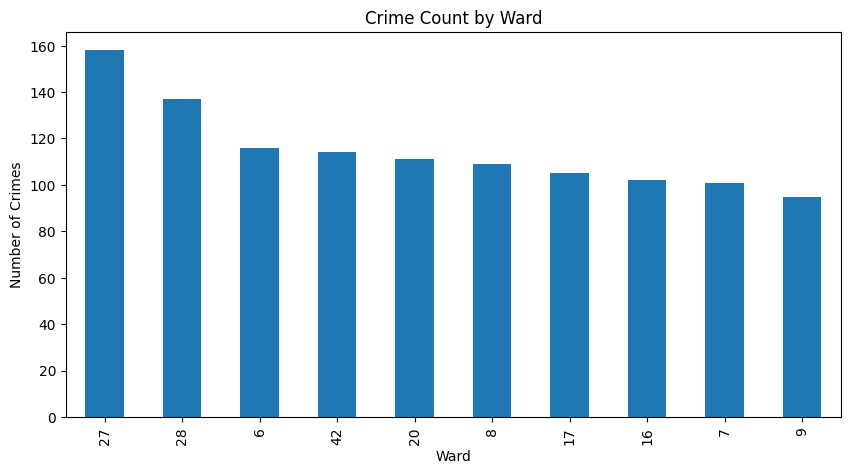

In [ ]:
Ward_wise_crime.sort_values(ascending=False).head(10).plot(kind='bar', figsize=(10,5))
plt.title('Crime Count by Ward')
plt.xlabel('Ward')
plt.ylabel('Number of Crimes')
plt.show()

What features/columns did you use?
I used the ward column.
ward represents the ward in which the reported crime record is associated.
groupby('ward') groups all crime records according to each ward.
.size() counts the number of records in each ward

What does the chart say?
The chart shows the number of reported crime records in each ward.
Each bar represents a ward.
The height of each bar represents the number of reported crime records in that ward

**Interpretation**
This chart helps us compare the distribution of reported crime records across different wards.

It allows us to identify wards with relatively higher or lower numbers of reported records.

This can help in further analysis of crime patterns at the ward level.

In [ ]:
community_area_wise_count = df.groupby('community_area').size()

In [ ]:

print(community_area_wise_count)

community_area
1     10
2     45
3     67
4     41
5     28
      ..
73    37
74     2
75    13
76    26
77    21
Length: 74, dtype: int64


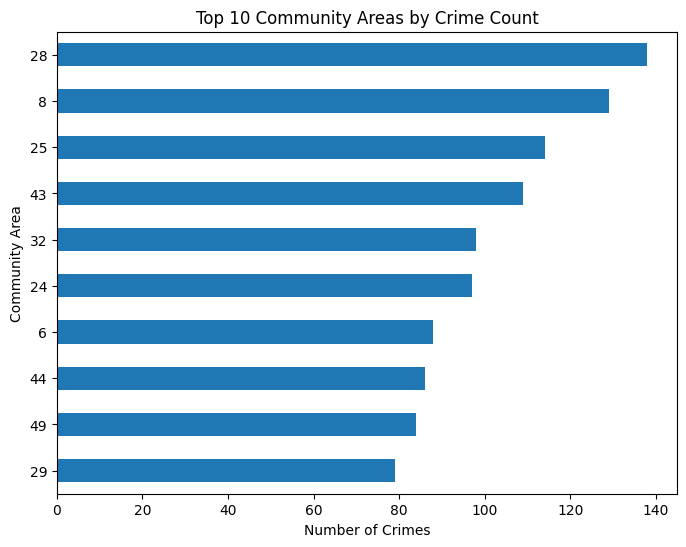

In [ ]:
community_area_wise_count.sort_values(ascending=False).head(10).plot(kind='barh', figsize=(8,6))
plt.title('Top 10 Community Areas by Crime Count')
plt.xlabel('Number of Crimes')
plt.ylabel('Community Area')
plt.gca().invert_yaxis()
plt.show()

What features/columns did you use?
I used the community_area column.
community_area represents the community area associated with the reported crime record.
groupby('community_area') groups the records based on each community area.
.size() counts the number of crime records in each community area.

What does the chart say?
The chart shows the number of reported crime records in each community area.
Each bar represents a community area.
The height of each bar represents the number of reported crime records in that area

**Interpretation**
This chart helps us understand how reported crime records are distributed across different community areas.

It allows us to compare areas with relatively higher or lower numbers of reported records.

This can help us identify areas that may need further investigation in the analysis.

In [ ]:
arrest_count= df.groupby('arrest').size()

In [ ]:
print(arrest_count)

arrest
False    2769
True      231
dtype: int64


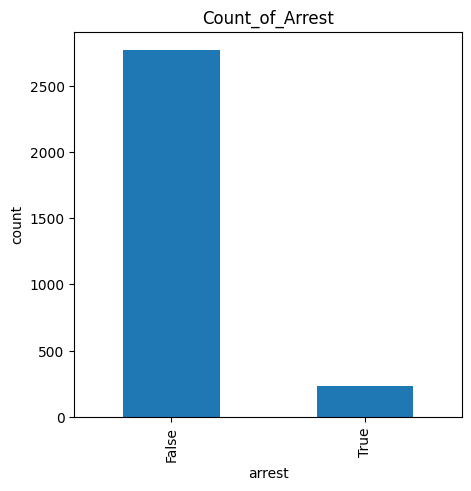

In [ ]:
arrest_count.plot (kind='bar', figsize=(5,5))
plt.title ('Count_of_Arrest')
plt.xlabel('arrest')
plt.ylabel('count')
plt.show()

What features/columns did you use?
I used the arrest column.
The arrest column indicates whether an arrest was made (True) or not made (False) for the reported crime record.
groupby('arrest') groups the records into True and False.
.size() counts the number of records in each group.

What does the chart say?
The chart shows the number of crime records that resulted in an arrest and those that did not.
The two categories are:
True → Arrest made
False → No arrest made
The height of each bar represents the number of records in that category.

**Interpretation**
This chart helps us compare arrested and non-arrested crime records.

It shows the proportion/count of reported crime records associated with an arrest.

We can use this information to understand the arrest outcome distribution in the dataset.

In [ ]:
domestic_wise_crime =df['domestic'].value_counts()

In [ ]:
print(domestic_wise_crime)

domestic
False    2328
True      672
Name: count, dtype: int64


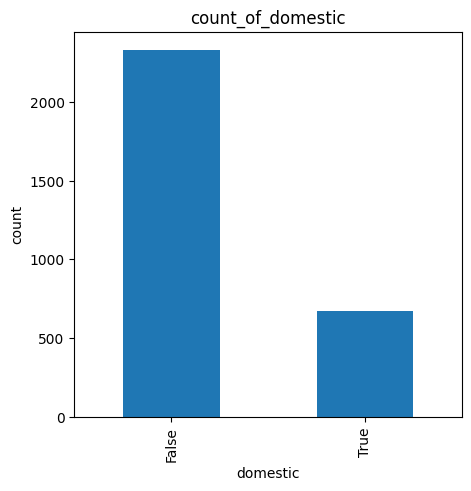

In [ ]:
domestic_wise_crime.plot(kind='bar', figsize=(5,5))
plt.title('count_of_domestic')
plt.xlabel('domestic')
plt.ylabel('count')
plt.show()

What features/columns did you use?
I used the domestic column.
The domestic column indicates whether the reported crime was classified as domestic (True) or non-domestic (False).
value_counts() directly counts how many times each value appears in the column.

What does the chart say?
The chart shows the number of reported crime records classified as domestic and non-domestic.
The two categories are:
True → Domestic crime
False → Non-domestic crime
The height of each bar represents the number of records in that category.

**Interpretation**
This chart helps us compare domestic and non-domestic reported crime records.
It shows how the reported crime records are distributed between these two categories.
This helps us understand whether domestic-related records form a smaller or larger portion of the dataset.

In [ ]:
df.head()

,unique_key,case_number,date,block,primary_type,description,location_description,arrest,domestic,beat,...,community_area,latitude,longitude,year,dates,time,hour,day_of_week,month,Crime_Description
0,13172384,JG378607,2023-08-11 14:35:00+00:00,001XX N MICHIGAN AVE,BATTERY,"AGGRAVATED - HANDS, FISTS, FEET, NO / MINOR IN...",SMALL RETAIL STORE,True,False,111,...,32,41.883644,-87.624420,2023,2023-08-11,14:35:00,14,Friday,August,AGGRAVATED
1,13276137,JG502918,2023-11-13 13:15:00+00:00,001XX N WABASH AVE,BATTERY,SIMPLE,SIDEWALK,False,False,111,...,32,41.885433,-87.626265,2023,2023-11-13,13:15:00,13,Monday,November,SIMPLE
2,12984870,JG155021,2023-02-16 16:10:00+00:00,001XX N WABASH AVE,BATTERY,SIMPLE,RESTAURANT,False,False,111,...,32,41.885301,-87.626267,2023,2023-02-16,16:10:00,16,Thursday,February,SIMPLE
3,13099278,JG291695,2023-06-07 11:32:00+00:00,001XX N STATE ST,BATTERY,"AGGRAVATED P.O. - HANDS, FISTS, FEET, SERIOUS ...",CTA PLATFORM,True,False,111,...,32,41.885482,-87.627936,2023,2023-06-07,11:32:00,11,Wednesday,June,AGGRAVATED
4,13053188,JG236699,2023-04-25 11:18:00+00:00,0000X E LAKE ST,ASSAULT,SIMPLE,STREET,False,False,111,...,32,41.885753,-87.626996,2023,2023-04-25,11:18:00,11,Tuesday,April,SIMPLE


In [ ]:
Month_wise_crime_count =  df['month'].value_counts()

In [ ]:
month_order = ['January', 'February', 'March', 'April', 'May', 'June',
               'July', 'August', 'September', 'October', 'November', 'December']

Month_wise_crime_count = Month_wise_crime_count.reindex(month_order)

In [ ]:
print(Month_wise_crime_count)

month
January      236
February     195
March        244
April        223
May          267
June         288
July         257
August       272
September    284
October      236
November     265
December     233
Name: count, dtype: int64


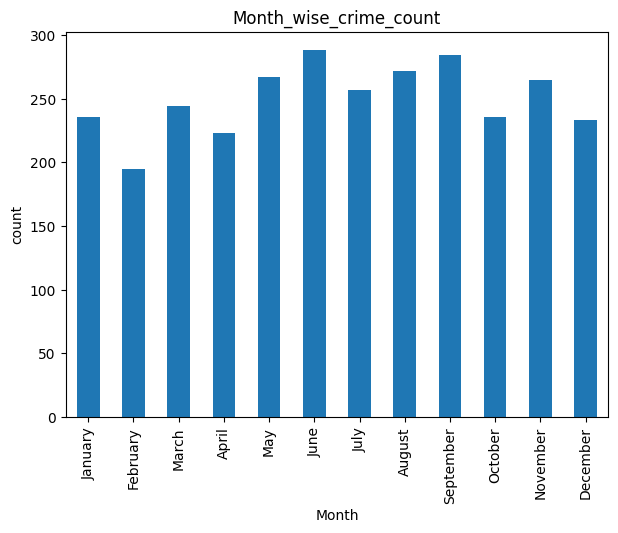

In [ ]:
Month_wise_crime_count.plot (kind='bar', figsize=(7,5))
plt.title ('Month_wise_crime_count')
plt.xlabel('Month')
plt.ylabel('count')
plt.show()

What features/columns did you use?
I used the month column.
The month column contains the month in which each crime was reported.
value_counts() counts how many crime records belong to each month.

What does the chart say?
The chart shows the number of reported crime records for each month.
Each bar represents a month.
The height of each bar represents the number of reported crime records in that month.

**Interpretation**
This chart helps us understand how reported crime records are distributed across different months.
We can compare the number of reported records between months.
It can help identify months with relatively higher or lower reported crime volumes.

In [ ]:
day_wise_crime_count= df['day_of_week'].value_counts()

In [ ]:
day_order = ['Sunday', 'Monday','Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday']
day_wise_crime_count =day_wise_crime_count.reindex(day_order)

In [ ]:
print(day_wise_crime_count)

day_of_week
Sunday       451
Monday       437
Tuesday      414
Wednesday    395
Thursday     420
Friday       447
Saturday     436
Name: count, dtype: int64


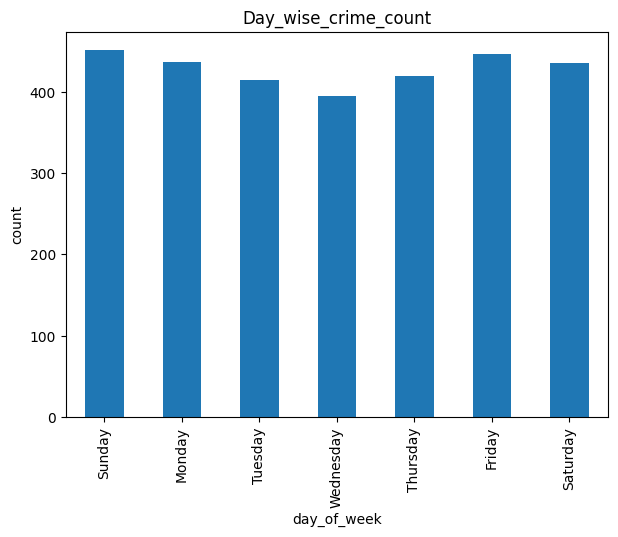

In [ ]:
day_wise_crime_count.plot (kind='bar', figsize=(7,5))
plt.title('Day_wise_crime_count')
plt.xlabel('day_of_week')
plt.ylabel('count')
plt.show()

What features/columns did you use?
I used the day_of_week column.
This column contains the day of the week on which each crime was reported.
value_counts() counts the number of crime records for each day.

What does the chart say?
The chart shows the number of reported crime records for each day of the week.
Each bar represents a day such as Monday, Tuesday, Wednesday, etc.
The height of each bar represents the number of reported crime records on that day.

**Interpretation**
This chart helps us understand how reported crime records are distributed across the days of the week.
We can compare the number of reported records between weekdays and weekends.
It helps identify days with relatively higher or lower reported crime volumes.

In [ ]:
date_wise_crime_count = df['dates'].value_counts()

In [ ]:
print(date_wise_crime_count)

dates
2023-06-24    17
2023-06-04    17
2023-09-27    16
2023-11-26    16
2023-09-24    15
              ..
2023-02-13     3
2023-02-12     2
2023-10-21     2
2023-10-03     1
2023-02-18     1
Name: count, Length: 364, dtype: int64


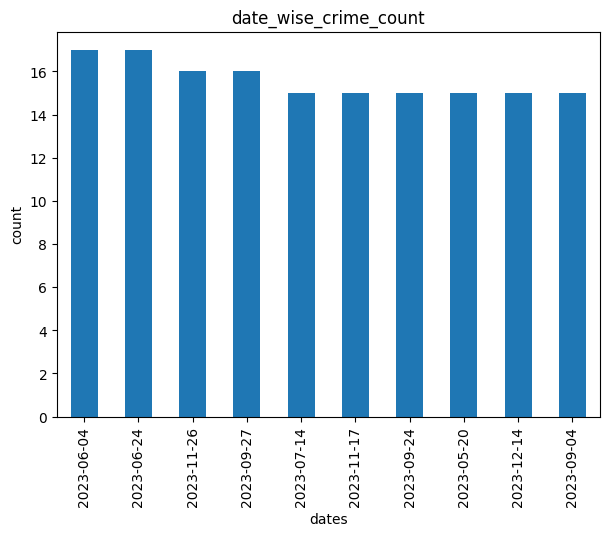

In [ ]:
date_wise_crime_count.sort_values(ascending=False).head(10).plot(kind='bar', figsize=(7,5))
plt.title('date_wise_crime_count')
plt.xlabel('dates')
plt.ylabel('count')
plt.show()

What features/columns did you use?
I used the dates column.
This column contains the date associated with each reported crime record.
value_counts() counts how many crime records occurred/reported on each date.

What does the chart say?
The chart shows the number of reported crime records for each date.
Each date is treated as a category.
The value represents the number of crime records recorded on that date.

**Interpretation**
This analysis helps us understand the daily distribution of reported crime records.
It can help identify dates with relatively higher or lower numbers of reported records.
This can also be useful for identifying unusual spikes in the daily crime records.

In [ ]:
time_wise_crime_count= df['time'].value_counts()

In [ ]:
print(time_wise_crime_count)

time
00:00:00    75
18:00:00    59
17:00:00    55
20:00:00    53
12:00:00    53
            ..
04:59:00     1
19:49:00     1
08:06:00     1
03:12:00     1
12:03:00     1
Name: count, Length: 820, dtype: int64


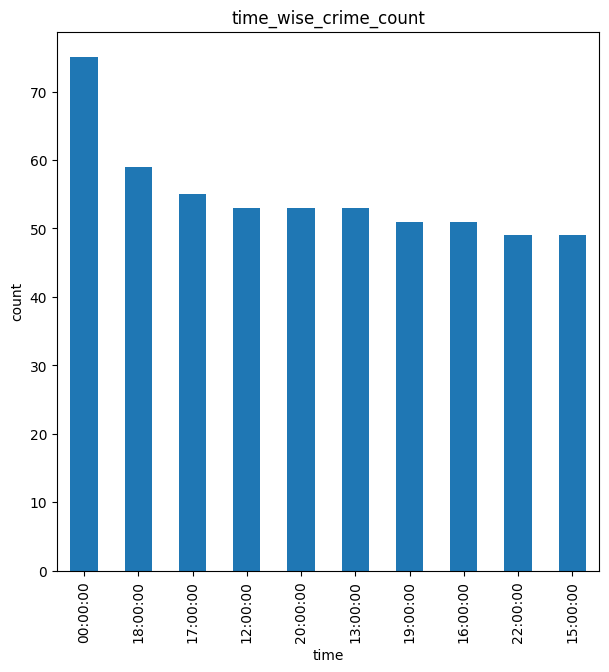

In [ ]:
time_wise_crime_count.sort_values(ascending=False).head(10).plot(kind='bar',figsize=(7,7))
plt.title('time_wise_crime_count')
plt.xlabel('time')
plt.ylabel('count')
plt.show()


What features/columns did you use?
I used the time column.
The time column contains the time associated with each reported crime record.
value_counts() counts how many crime records are recorded at each time.

What does the chart say?
The chart shows the number of reported crime records at different times.
Each time value is represented as a category.
The value/count represents the number of crime records associated with that time.

**Interpretation**
This analysis helps us understand the distribution of reported crime records throughout the day.
It can help identify time periods where the number of reported records is relatively higher or lower.
This can provide a basis for further analysis of crime patterns by time.

In [ ]:
location_wise_crime= df.groupby('location_description').size()

In [ ]:
print(location_wise_crime)

location_description
AIRCRAFT                                            1
AIRPORT BUILDING NON-TERMINAL - NON-SECURE AREA     1
AIRPORT EXTERIOR - NON-SECURE AREA                  2
AIRPORT PARKING LOT                                 2
AIRPORT TERMINAL LOWER LEVEL - NON-SECURE AREA      2
                                                   ..
TAXICAB                                             1
VACANT LOT / LAND                                   8
VEHICLE - COMMERCIAL                                6
VEHICLE - DELIVERY TRUCK                            1
VEHICLE NON-COMMERCIAL                             47
Length: 76, dtype: int64


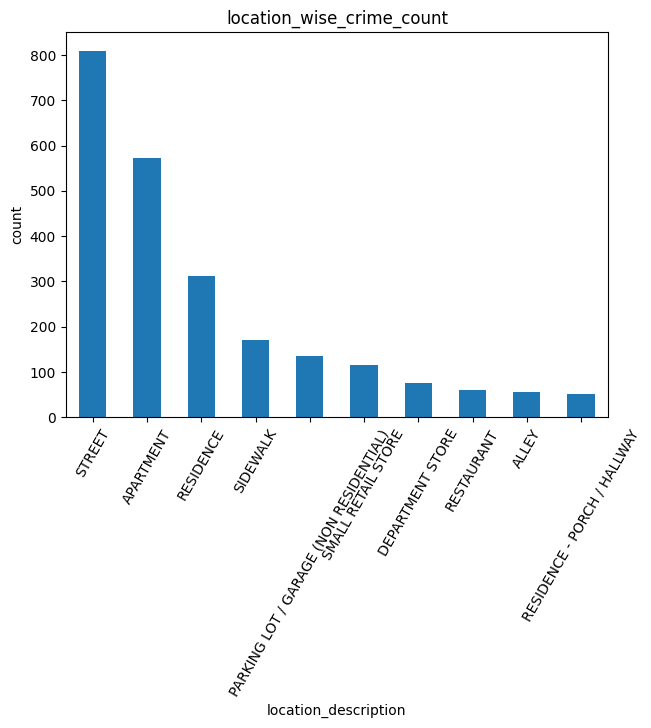

In [ ]:
location_wise_crime.sort_values(ascending=False).head(10).plot(kind='bar', figsize=(7,5))
plt.title('location_wise_crime_count')
plt.xlabel('location_description')
plt.ylabel('count')
plt.xticks(rotation=60)
plt.show()

What features/columns did you use?
I used the location_description column.
This column describes the location type where the crime was reported, such as a street, residence, parking lot, etc.
groupby('location_description') groups the crime records according to their location type.
.size() counts the number of records in each location category.

What does the chart say?
The chart shows the number of reported crime records for each location type.
Each bar represents a different location category.
The height of each bar represents the number of reported crime records associated with that location.

**Interpretation**
This chart helps us understand where reported crimes are more frequently recorded.
We can compare different location types and identify categories with relatively higher or lower numbers of reported records.
This can help us perform further analysis based on crime location patterns.

Bivariate Analysis

In [ ]:
#Analysis about the Crime Type vs Arrest — Bar Plot

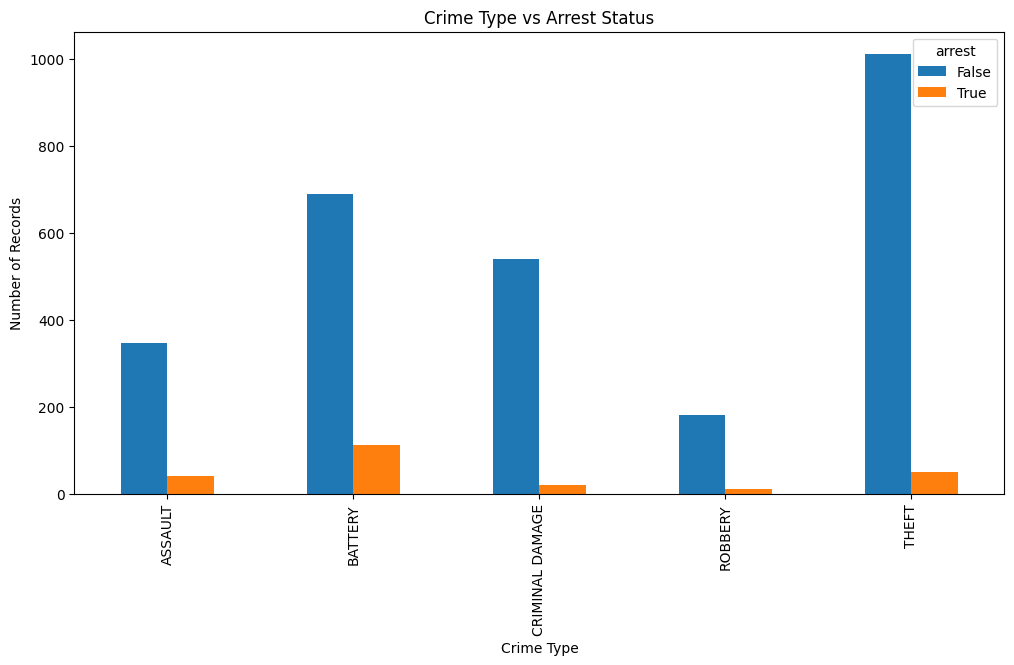

In [ ]:
crime_arrest = pd.crosstab(df['primary_type'], df['arrest'])

crime_arrest.plot(kind='bar', figsize=(12,6))

plt.xlabel('Crime Type')
plt.ylabel('Number of Records')
plt.title('Crime Type vs Arrest Status')
plt.xticks(rotation=90)
plt.show()

What features did I use?

primary_type
arrest


What does the chart say?
It compares how many records resulted in an arrest and how many did not for each crime type.

**Interpretation:**
“I am analyzing the relationship between crime type and arrest status to understand how arrest outcomes vary across different types of reported crimes.”

In [ ]:
#Analysis about the Crime Type vs Domestic — Bar Plot

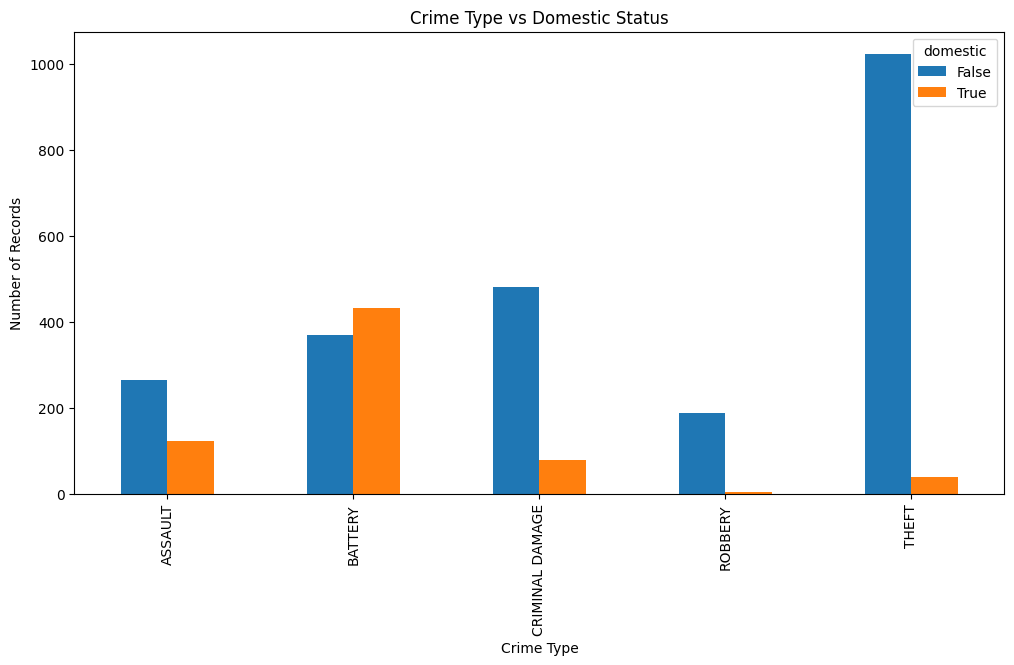

In [ ]:
crime_domestic = pd.crosstab(df['primary_type'], df['domestic'])

crime_domestic.plot(kind='bar', figsize=(12,6))

plt.xlabel('Crime Type')
plt.ylabel('Number of Records')
plt.title('Crime Type vs Domestic Status')
plt.xticks(rotation=90)
plt.show()

Features used:

primary_type,
domestic


What does the chart say?
It compares domestic and non-domestic records across different crime types.

**Interpretation:**
“I am analyzing the relationship between crime type and domestic status to understand which crime categories are more associated with domestic incidents.”

In [ ]:
#Analysis about the  crime time (Hour vs Crime Count) — Line Plot

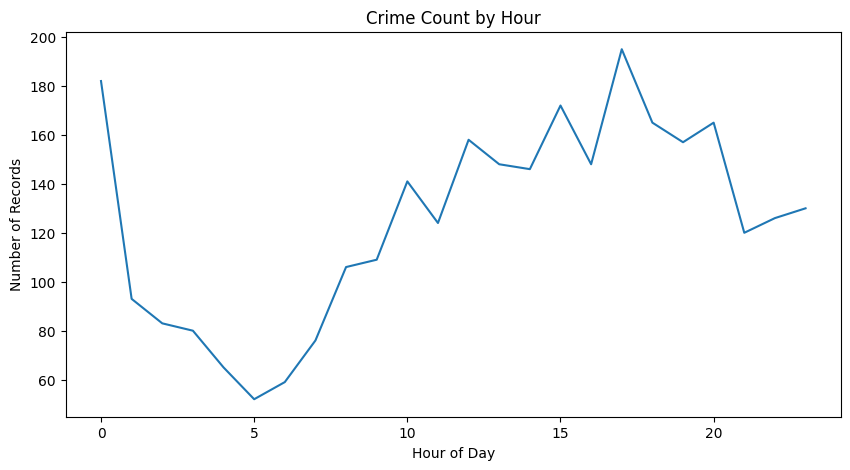

In [ ]:
hour_wise_crime = df.groupby('hour').size()

hour_wise_crime.plot(kind='line', figsize=(10,5))

plt.xlabel('Hour of Day')
plt.ylabel('Number of Records')
plt.title('Crime Count by Hour')

plt.show()

In [ ]:
df.columns.tolist()

['unique_key',
 'case_number',
 'date',
 'block',
 'primary_type',
 'description',
 'location_description',
 'arrest',
 'domestic',
 'beat',
 'district',
 'ward',
 'community_area',
 'latitude',
 'longitude',
 'year',
 'dates',
 'time',
 'hour',
 'day_of_week',
 'month',
 'Crime_Description']

Features used:

hour,
crime record count

What does the chart say?
It shows how the number of reported crime records changes throughout the day.

**Interpretation:**
“I am analyzing the relationship between time of day and reported crime volume to identify the hours when crime records are more or less frequently reported.”

In [ ]:
#Analysis about the geographical Latitude vs Longitude — Scatter Plot

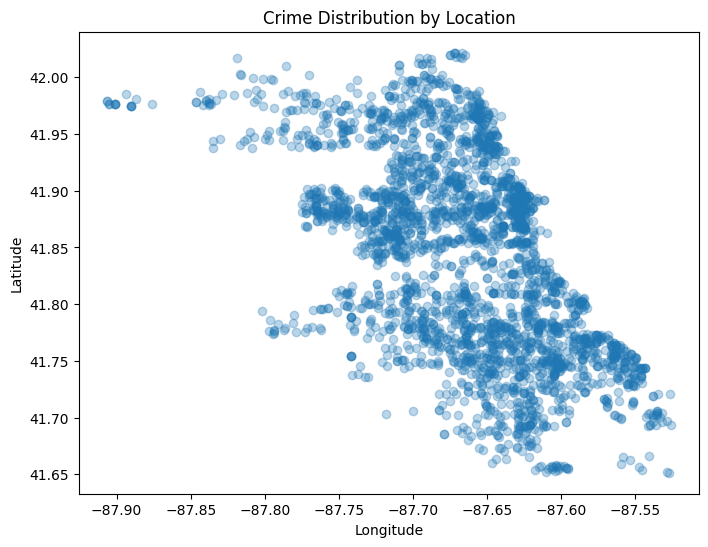

In [ ]:
plt.figure(figsize=(8,6))

plt.scatter(df['longitude'], df['latitude'], alpha=0.3)

plt.xlabel('Longitude')
plt.ylabel('Latitude')
plt.title('Crime Distribution by Location')

plt.show()



Features used:

longitude
latitude

What does the chart say?
Each point represents a crime record's geographical location.

**Interpretation:**
“I am analyzing the relationship between latitude and longitude to understand the geographical distribution of reported crime records.”

In [ ]:
# Analysis about the Correlation  — Numerical Variables

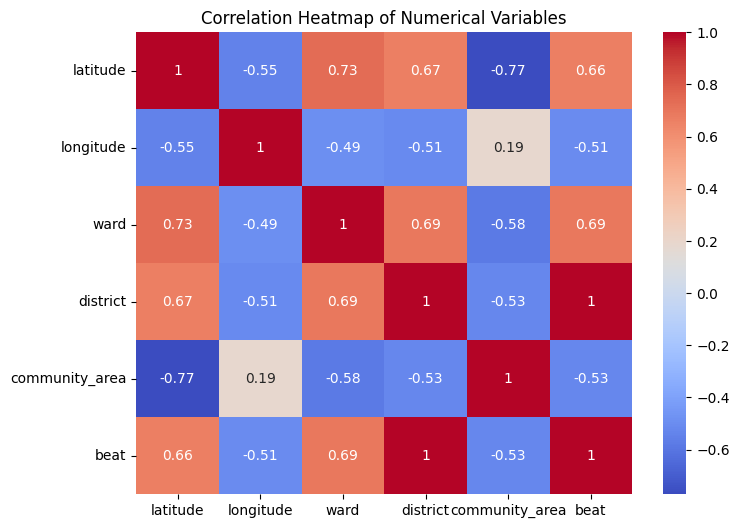

In [ ]:
numeric_cols = [
    'latitude',
    'longitude',
    'ward',
    'district',
    'community_area',
    'beat'
]

corr = df[numeric_cols].corr()

plt.figure(figsize=(8,6))

sns.heatmap(
    corr,
    annot=True,
    cmap='coolwarm'
)

plt.title('Correlation Heatmap of Numerical Variables')
plt.show()

Features used:

latitude,
longitude,
ward,
district,
community_area,
beat,

What does the chart say?
The heatmap shows the strength and direction of correlation between numerical variables.

**Interpretation:**
“I am analyzing the correlation between numerical variables to understand whether there is any linear relationship between them.”

In [ ]:
# Analysis about the primary_type × location_description

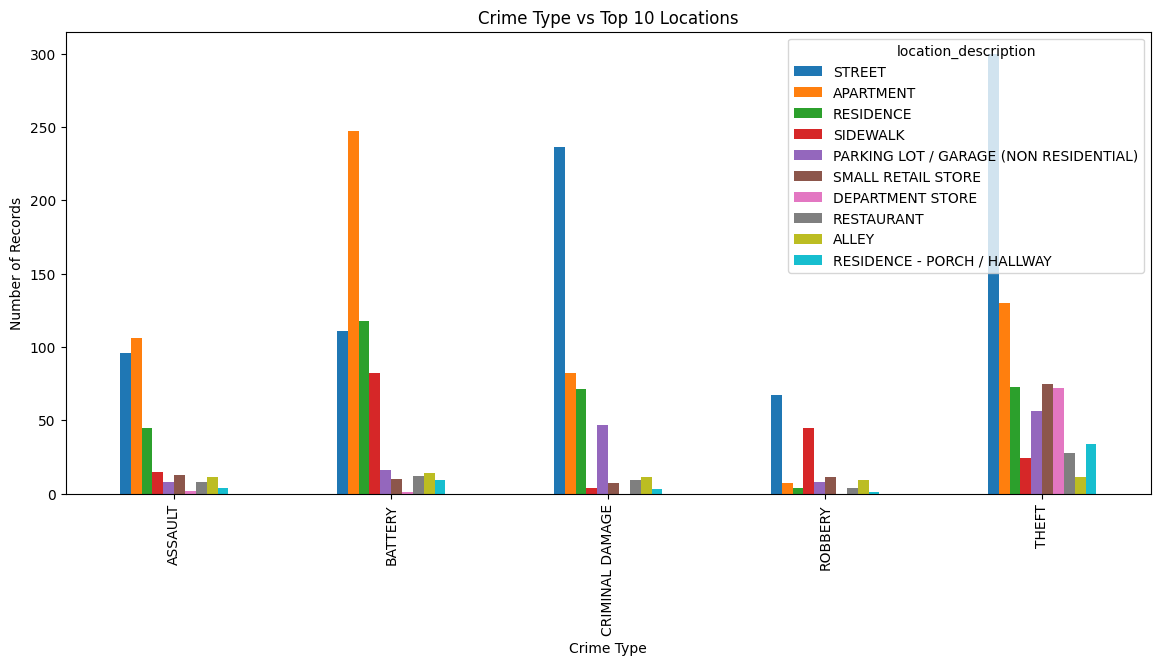

In [ ]:
top_locations = df['location_description'].value_counts().head(10).index

crime_location = pd.crosstab(
    df['primary_type'],
    df['location_description']
)[top_locations]

crime_location.plot(kind='bar',figsize=(14, 6))
plt.xlabel('Crime Type')
plt.ylabel('Number of Records')
plt.title('Crime Type vs Top 10 Locations')
plt.xticks(rotation=90)
plt.show()

What features/columns did I use?

primary_type,
location_description

What does the chart say?
It compares different crime types across the most common location categories.

**Interpretation:**

“I am analyzing the relationship between crime type and location description to understand how different types of reported crimes are distributed across common locations.”

In [ ]:
#multi variate

In [ ]:
# Analysis about the Crime Type + Arrest + District

In [ ]:
crime_district_arrest = pd.crosstab(
    [df['district'], df['primary_type']],
    df['arrest']
)

crime_district_arrest.head()

arrest                    False  True 
district primary_type                 
1        ASSAULT             10      2
         BATTERY             27      9
         CRIMINAL DAMAGE     16      4
         ROBBERY             11      0
         THEFT               78      9

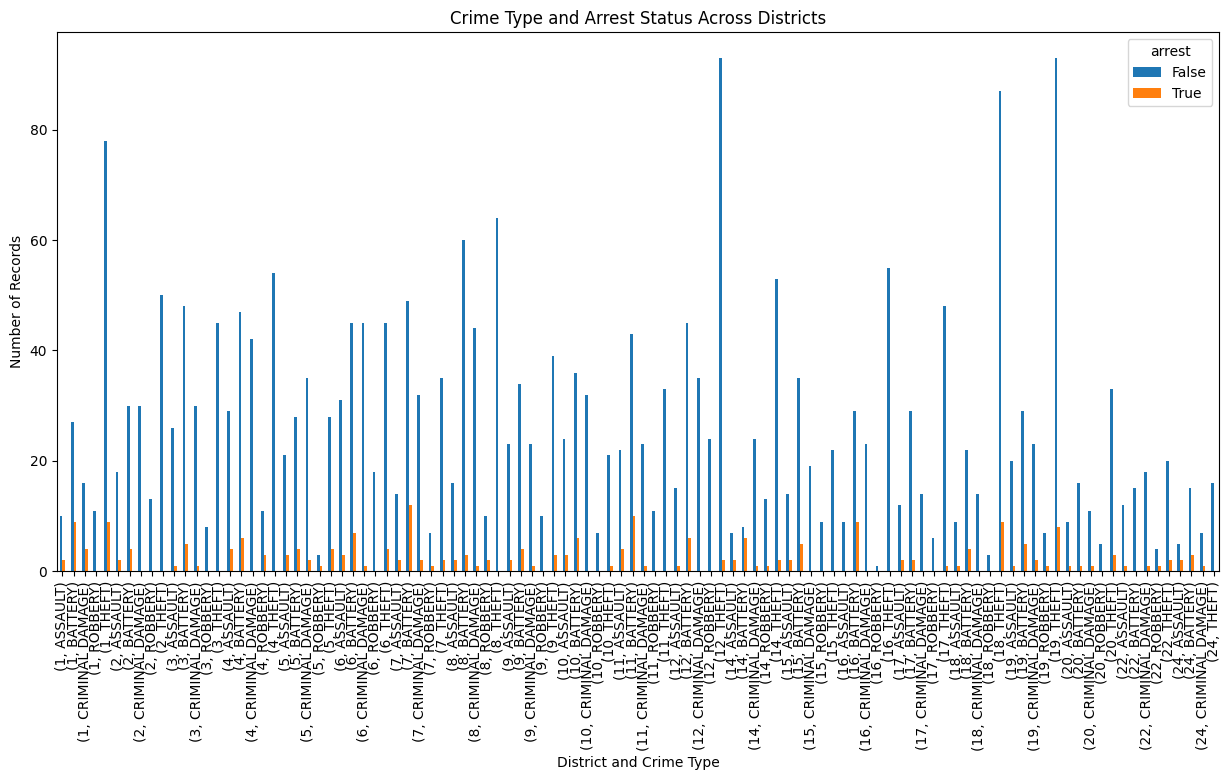

In [ ]:
crime_district_arrest.plot(
    kind='bar',
    figsize=(15, 7)
)

plt.xlabel('District and Crime Type')
plt.ylabel('Number of Records')
plt.title('Crime Type and Arrest Status Across Districts')
plt.show()

What features did I use?

district, primary_type, and arrest.

What does the chart say?

It shows how different crime types and arrest outcomes vary across different districts.

**Interpretation**

“An analyzing crime type and arrest status across different districts to understand how crime patterns and arrest outcomes vary by district.”

In [ ]:
# Analysis about the Crime Type + Domestic + District

In [ ]:
crime_district_domestic = pd.crosstab(
    [df['district'], df['primary_type']],
    df['domestic']
)

crime_district_domestic.head(2)

domestic               False  True 
district primary_type              
1        ASSAULT          12      0
         BATTERY          19     17

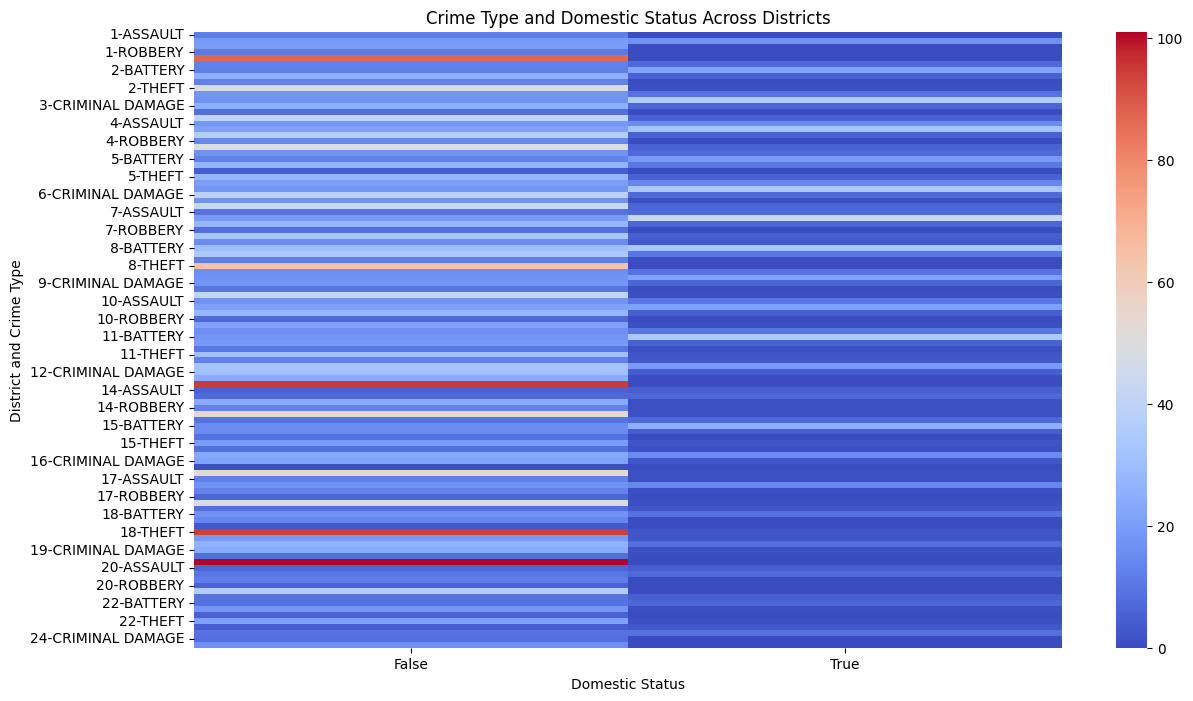

In [ ]:
plt.figure(figsize=(14,8))

sns.heatmap(
    crime_district_domestic,
    annot=False,
    cmap='coolwarm'
)

plt.title('Crime Type and Domestic Status Across Districts')
plt.xlabel('Domestic Status')
plt.ylabel('District and Crime Type')
plt.show()

What features did I use?

district, primary_type, and domestic.

What does the chart say?

It compares domestic and non-domestic records for different crime types across districts.

**Interpretation**

“I am analyzing crime type and domestic status across different districts to understand how domestic and non-domestic crime patterns vary by location.”

In [ ]:
#Analysis about the crime types vary across different days of the week. Heatmap

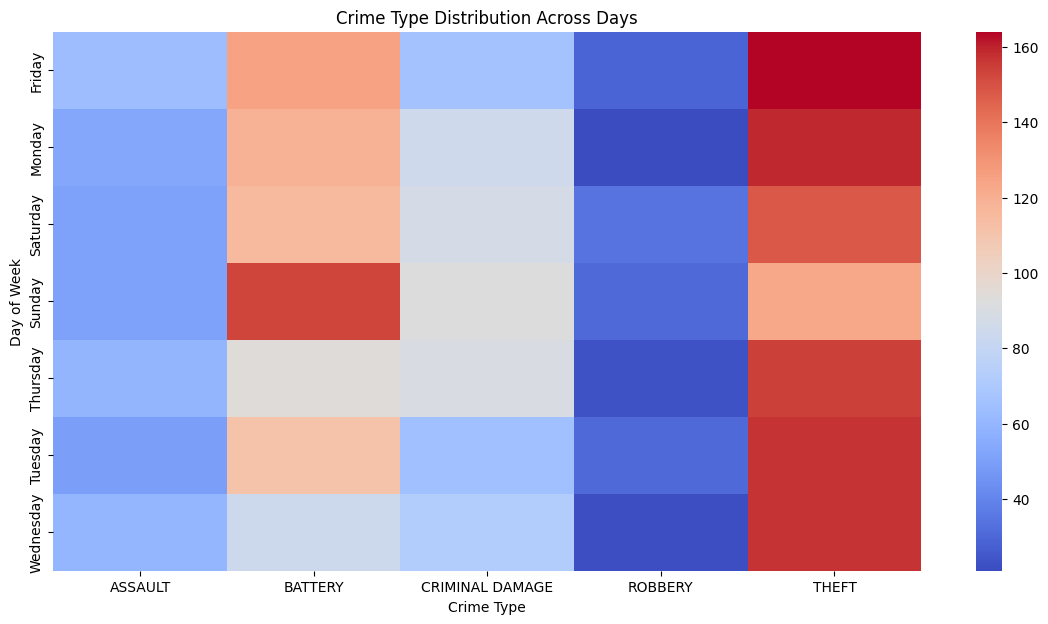

In [ ]:
crime_day_type = pd.crosstab(
    df['day_of_week'],
    df['primary_type']
)

plt.figure(figsize=(14, 7))

sns.heatmap(
    crime_day_type,
    cmap='coolwarm'
)

plt.xlabel('Crime Type')
plt.ylabel('Day of Week')
plt.title('Crime Type Distribution Across Days')
plt.show()

What features did I use?

day_of_week and primary_type, with the number of records represented by the heatmap values.

What does the chart say?

The chart shows how different crime types are distributed across different days of the week.



**Interpretation**

“I am analyzing crime type across different days of the week to understand whether the distribution of reported crime varies by day and crime category.”

In [ ]:
#Analysis about the numeric columns and their distribution

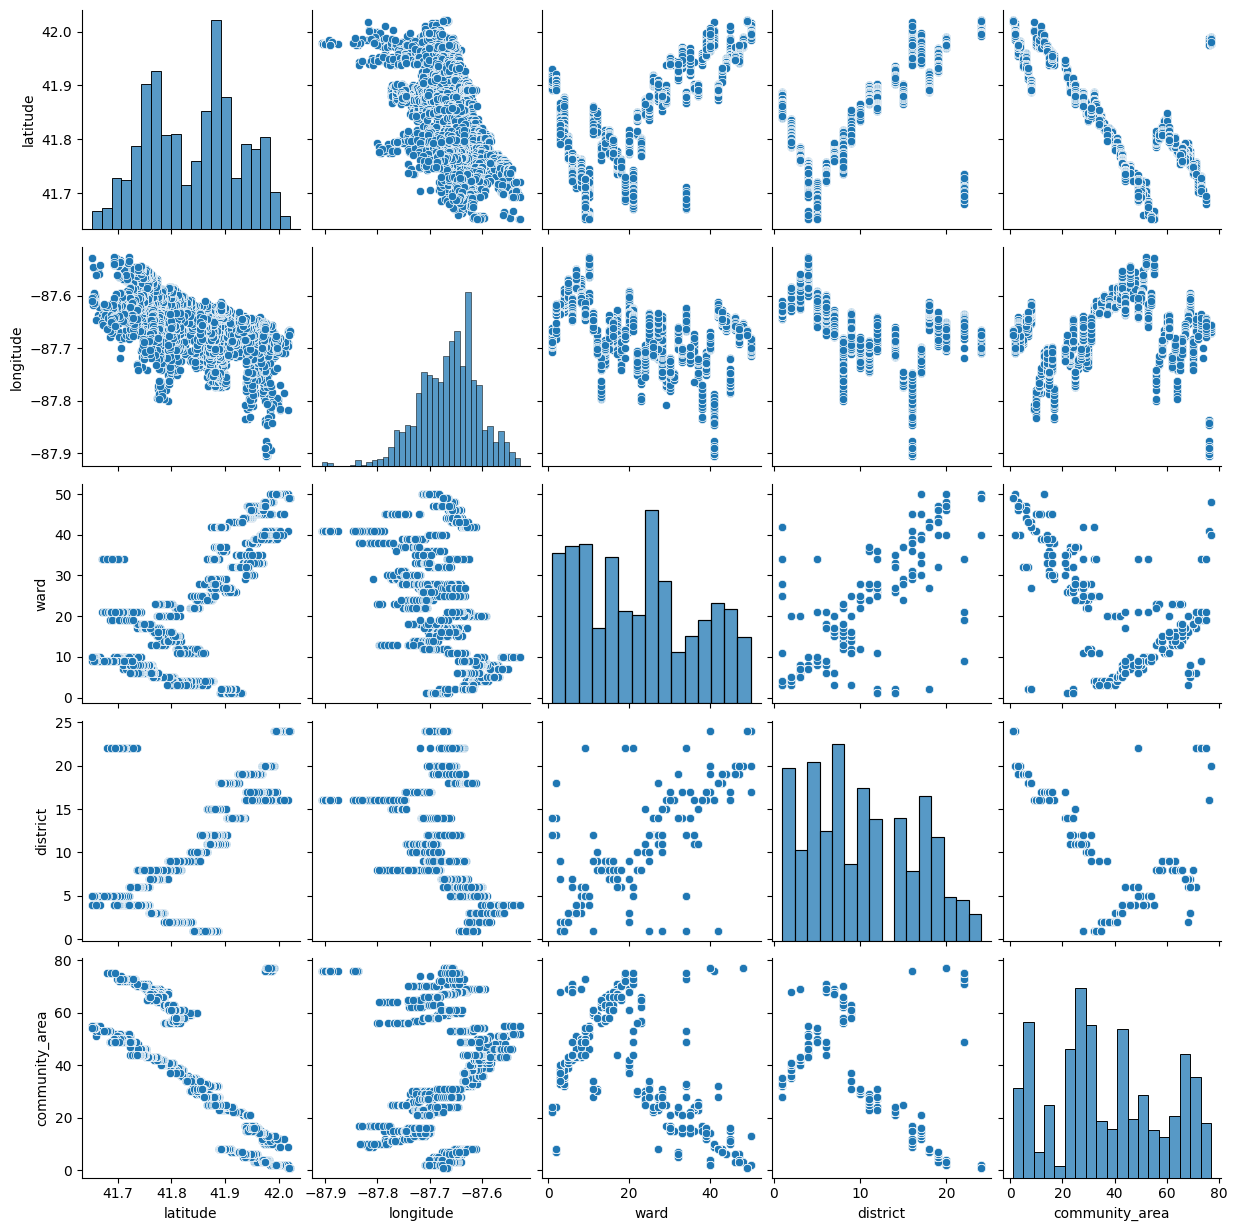

In [ ]:
numeric_cols = [
    'latitude',
    'longitude',
    'ward',
    'district',
    'community_area'
]

sns.pairplot(df[numeric_cols])

plt.show()

Features used:
latitude, longitude, ward, district, community_area

What does the chart say?
It shows the pairwise relationships and distributions among multiple numerical variables.

**Interpretation:**

“I am using a pairplot to analyze the relationships between multiple numerical variables and identify patterns, distributions, and possible correlations among them.”

Features used:
longitude, latitude, primary_type

What does the chart say?
It shows where crime records are geographically located and distinguishes different crime types.

In [ ]:
#Analysis about the geographical crime and types(Latitude + Longitude + Crime Type)

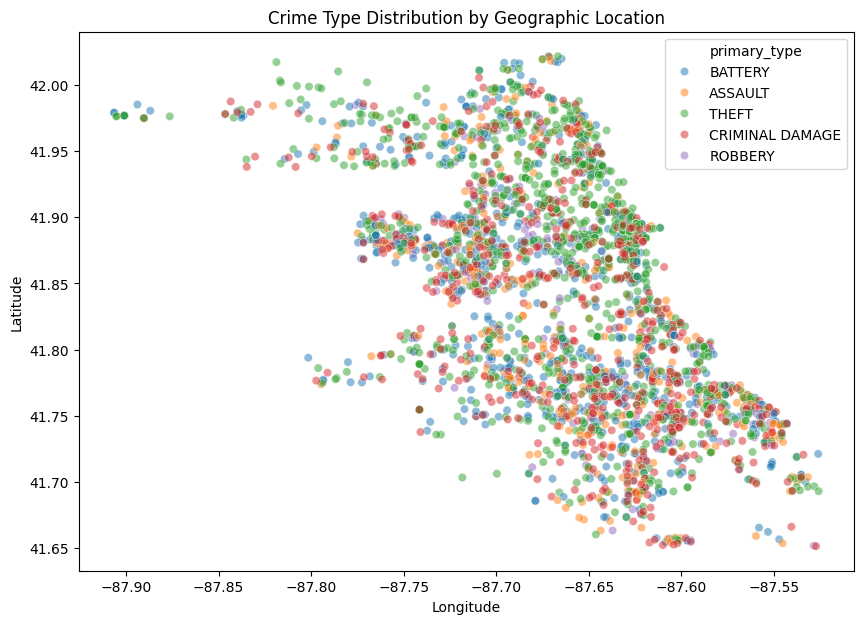

In [ ]:
plt.figure(figsize=(10, 7))

sns.scatterplot(
    data=df,
    x='longitude',
    y='latitude',
    hue='primary_type',
    alpha=0.5
)

plt.title('Crime Type Distribution by Geographic Location')
plt.xlabel('Longitude')
plt.ylabel('Latitude')
plt.show()

What features did I use?

longitude, latitude, and primary_type.

What does the chart say?

It shows the geographical distribution of crime records while distinguishing between different crime types.

**Interpretation**

“An analyzing the geographical distribution of different crime types using latitude and longitude to understand how crime categories are distributed across locations.”

Advanced analsis using Histogram

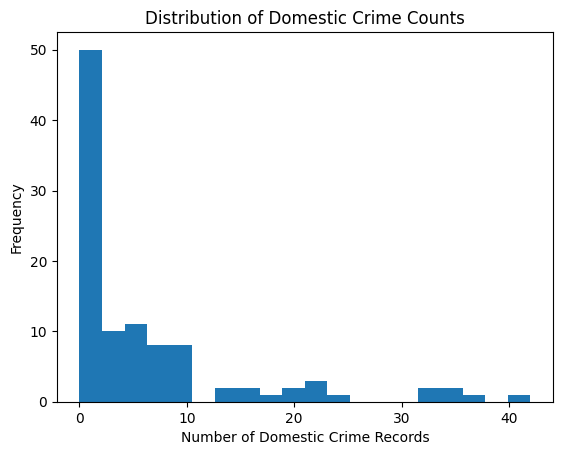

In [ ]:
crime_district_domestic[True].plot(kind='hist', bins=20)

plt.xlabel('Number of Domestic Crime Records')
plt.ylabel('Frequency')
plt.title('Distribution of Domestic Crime Counts')
plt.show()

Analysis: “I am analyzing the distribution of domestic crime counts across different district and crime-type combinations.”

**Interpretation: **“The histogram shows how the domestic crime counts are distributed, helping us identify whether most combinations have low, medium, or high crime counts.”

In [ ]:
df.columns

Index(['unique_key', 'case_number', 'date', 'block', 'primary_type',
       'description', 'location_description', 'arrest', 'domestic', 'beat',
       'district', 'ward', 'community_area', 'latitude', 'longitude', 'year',
       'dates', 'time', 'hour', 'day_of_week', 'month', 'Crime_Description'],
      dtype='object')

#Downloading the cleaned data set

In [ ]:
df.columns

Index(['unique_key', 'case_number', 'date', 'block', 'primary_type',
       'description', 'location_description', 'arrest', 'domestic', 'beat',
       'district', 'ward', 'community_area', 'latitude', 'longitude', 'year',
       'dates', 'time', 'hour', 'day_of_week', 'month', 'Crime_Description'],
      dtype='object')

In [ ]:

df=pd.read_csv('chicago_crime_2023.csv.csv')
df.to_csv("cleaned_chicago_crime.csv")

In [ ]:
df.to_csv('chicago_crime_cleaned.csv', index=False)

In [ ]:
df.columns.tolist()

['unique_key',
 'case_number',
 'date',
 'block',
 'primary_type',
 'description',
 'location_description',
 'arrest',
 'domestic',
 'beat',
 'district',
 'ward',
 'community_area',
 'fbi_code',
 'latitude',
 'longitude',
 'year']

In [ ]:
df.columns.tolist()

['unique_key',
 'case_number',
 'date',
 'block',
 'primary_type',
 'description',
 'location_description',
 'arrest',
 'domestic',
 'beat',
 'district',
 'ward',
 'community_area',
 'fbi_code',
 'latitude',
 'longitude',
 'year']

In [ ]:
df.shape

(3000, 17)

In [ ]:
%whos

Variable                    Type         Data/Info
--------------------------------------------------
Month_wise_crime_count      Series       month\nJanuary      236\n<...>Name: count, dtype: int64
Ward_wise_crime             Series       ward\n1      57\n2      3<...>\n50     39\ndtype: int64
arrest_count                Series       arrest\nFalse    2769\nTr<...>ue      231\ndtype: int64
community_area_wise_count   Series       community_area\n1     10\<...>nLength: 74, dtype: int64
corr                        DataFrame                    latitude <...>eat            1.000000  
crime_arrest                DataFrame    arrest           False  T<...>T             1012     50
crime_day_type              DataFrame    primary_type  ASSAULT  BA<...>       72       22    157
crime_district_arrest       DataFrame    arrest                   <...>n\n[104 rows x 2 columns]
crime_district_domestic     DataFrame    domestic                 <...>n\n[104 rows x 2 columns]
crime_domestic           

In [ ]:
from google.colab import files
files.download('chicago_crime_cleaned.csv')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>


**Stage 4 – Documentation, Insights and Presentation**

**Final Overall Insights:**


Theft and Battery drive most crime. Theft is 35.4% of records (1,062) and Battery is 26.7% (801), so the two together make up about 62% of the 3,000 crimes. Cutting these two would reduce the total more than any other single action.


A few districts hold a third of the crime. Districts 12, 8, 6, 4 and 19 account for 1,007 of the 3,000 crimes, about 34% from only 5 of the 21 districts. These are the clearest hotspots for patrol planning.


Very few crimes end in an arrest. Only 231 of 3,000 crimes (7.7%) led to an arrest. This is the biggest gap in the data, and it points to a need to look at investigation and resolution, especially for the crime types with the lowest rates.


About one in four crimes is domestic. 672 records (22.4%) were flagged as domestic. This is a large share, so it needs its own response and victim-support approach, separate from street crime.


Crime is steady, with no quiet period. Crimes were recorded on all 364 days, averaging about 8 per day. Even the quietest weekday (Wednesday, 395) is close to the busiest (Sunday, 451), so coverage should stay consistent across the week and not be cut on any one day.

**Future Enhancements:**



1.*Use the full dataset and more year*s. The project uses a 3,000-record sample of five crime types for one year. Using all crime types and several years from BigQuery would make the patterns more reliable. It would also let you compare year over year and spot long-term trends.

2.*Add population data to get true crime rates*. District counts don't account for how many people live there, so a high count doesn't always mean higher risk. Adding population per district would let you calculate crimes per 100,000 people and compare districts fairly.


3.*Build a forecasting model.* With more years of data, you could predict monthly or daily crime volume using time series methods in Python or the Power BI forecast feature. This would add the predictive analysis that is missing today and help plan staffing ahead of time.



4.Add a what-if scenario to the dashboard. *italicised text* A slider for "reduce crime by X% in the top districts" would show the projected effect on the total. It would support the prescriptive part of the project, as long as it is labelled a scenario and not a guaranteed result.


5.*Automate and publish the dashboard. *Connect Power BI directly to BigQuery, schedule a refresh, and publish to Power BI Service. The dashboard would then update with new crime data without manual downloads, and stakeholders could view it online.

6.*Add outside factors to explain the patterns.* Weather, holidays, major events and unemployment data could help show why crime rises on certain days or months. This would strengthen the diagnostic part of the project, which currently shows patterns but can't fully explain them.

**Conclusion:**


This project analyzed 3,000 Chicago crime records from 2023, covering five crime types, using Python for cleaning and exploration and Power BI for the star-schema model and dashboard. The goal was to understand what crimes happen, where, when, and how often they end in an arrest.

The analysis showed that crime is concentrated. Theft and Battery make up about 62% of all records, and five districts (12, 8, 6, 4 and 19) account for about 34% of crimes. Only 7.7% of crimes ended in an arrest, and about 22.4% were domestic. Crime was recorded on all 364 days, with only a small difference between the busiest day (Sunday) and the quietest (Wednesday).

These findings support three clear actions: focus patrols on the five busiest districts, target prevention at Theft and Battery, and look into why so few crimes lead to an arrest. Domestic incidents also need their own response, and staffing should stay steady across the whole week.